# Deconvolved origins of replication analysis

Form a consensus origin and perform correlations on all origins against this consensus origin to analyze early and late firing signals.

In [3]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Origins of Replication Deconvolution Analysis - Composite Plots
Evaluation of overall signal for construction of canonical origin. Goal will be to create this canonical origin and correlate with all other origins, to get get a correlation shift score. And characterize the timing of all origins.

In [619]:
from pipeline.deconvolved_origin_analysis import DeconvolvedOriginAnalysis
chromatin_data_path_nodaughter = \
    'output/prototype_pipeline_subset/chromatin_deconvolution_no_daughter/deconvolution_data/'
deconv_origin_analysis_no_daughter = DeconvolvedOriginAnalysis(chromatin_data_path=chromatin_data_path_nodaughter)


In [620]:
dat = deconv_origin_analysis_no_daughter.generate_summary_histogram_data()

Generating summary histogram data for all timepoints...
Initializing data arrays with: 239 origins, 149 timepoints, 100 positions
  Processing chromosome 1 (6 origins) - 00:00:00.221
  Processing chromosome 2 (13 origins) - 00:00:01.221
  Processing chromosome 3 (10 origins) - 00:00:03.130
  Processing chromosome 4 (29 origins) - 00:00:04.622
  Processing chromosome 5 (10 origins) - 00:00:08.933
  Processing chromosome 6 (7 origins) - 00:00:10.425
  Processing chromosome 7 (19 origins) - 00:00:11.442
  Processing chromosome 8 (12 origins) - 00:00:14.261
  Processing chromosome 9 (10 origins) - 00:00:16.145
  Processing chromosome 10 (13 origins) - 00:00:17.636
  Processing chromosome 11 (14 origins) - 00:00:19.665
  Processing chromosome 12 (26 origins) - 00:00:21.794
  Processing chromosome 13 (17 origins) - 00:00:25.690
  Processing chromosome 14 (14 origins) - 00:00:28.419
  Processing chromosome 15 (22 origins) - 00:00:30.513
  Processing chromosome 16 (17 origins) - 00:00:34.054
C

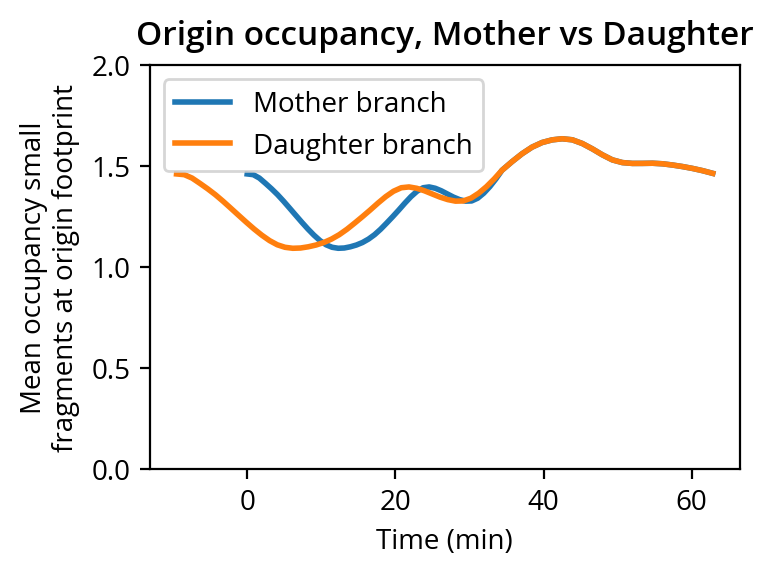

In [784]:
fig = deconv_origin_analysis_no_daughter.plot_small_fragment_occupancy_comparison()

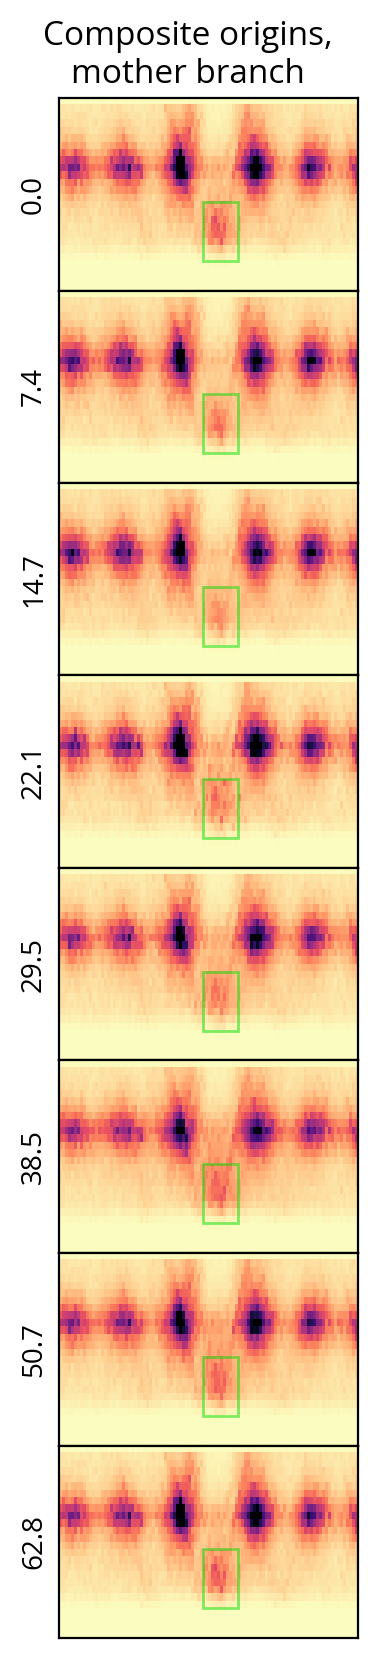

In [863]:
fig = deconv_origin_analysis_no_daughter.plot_composite_histograms('t', max_value=2000,
                                                               highlight_center=True)

In [638]:
from pipeline.origin_consensus_correlation import OriginConsensusCorrelationAnalysis

# Initialize the analysis
consensus_analysis = OriginConsensusCorrelationAnalysis(deconv_origin_analysis_no_daughter)


In [639]:
# Compute correlations with optimal shifts
results = consensus_analysis.compute_correlations(
    shift_range=(-10, 10),
    find_optimal_shift=True,
    time_indices=t_indices
)

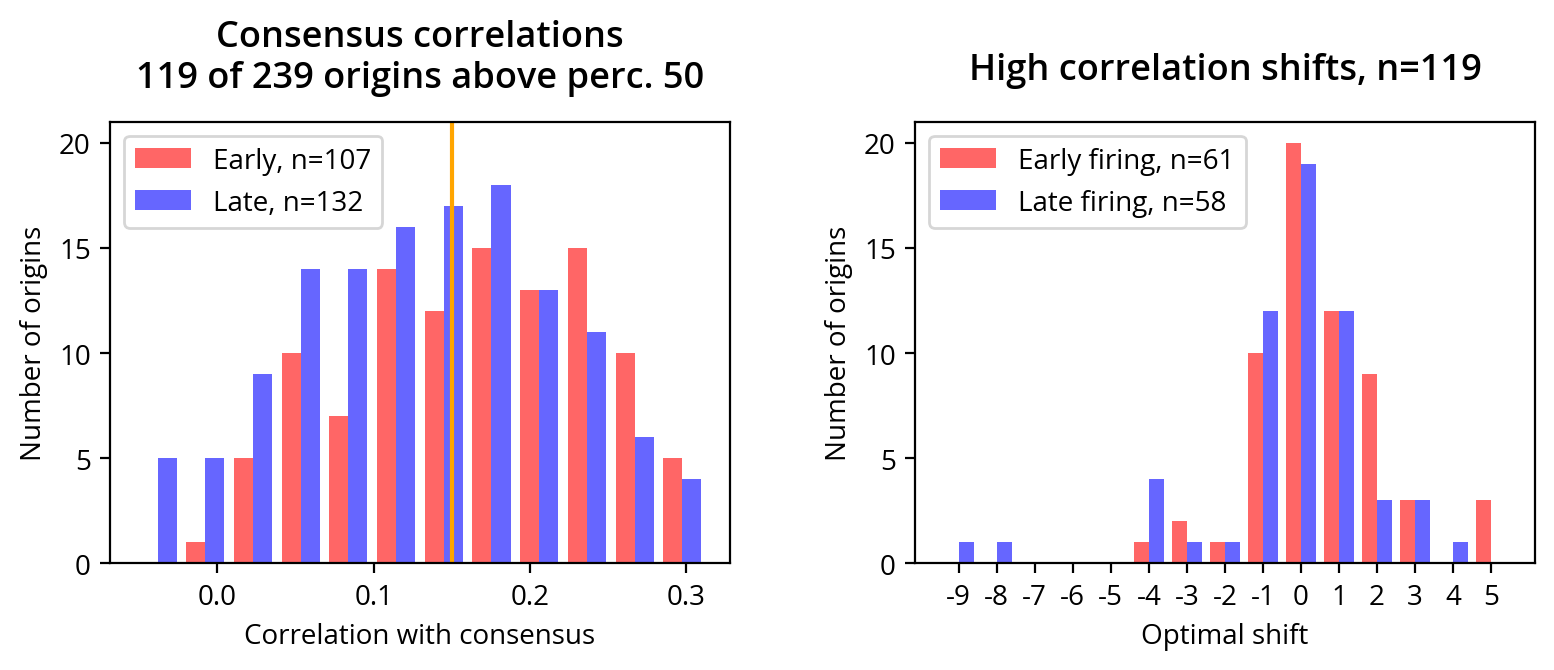

In [933]:
consensus_analysis.plot_distributions()

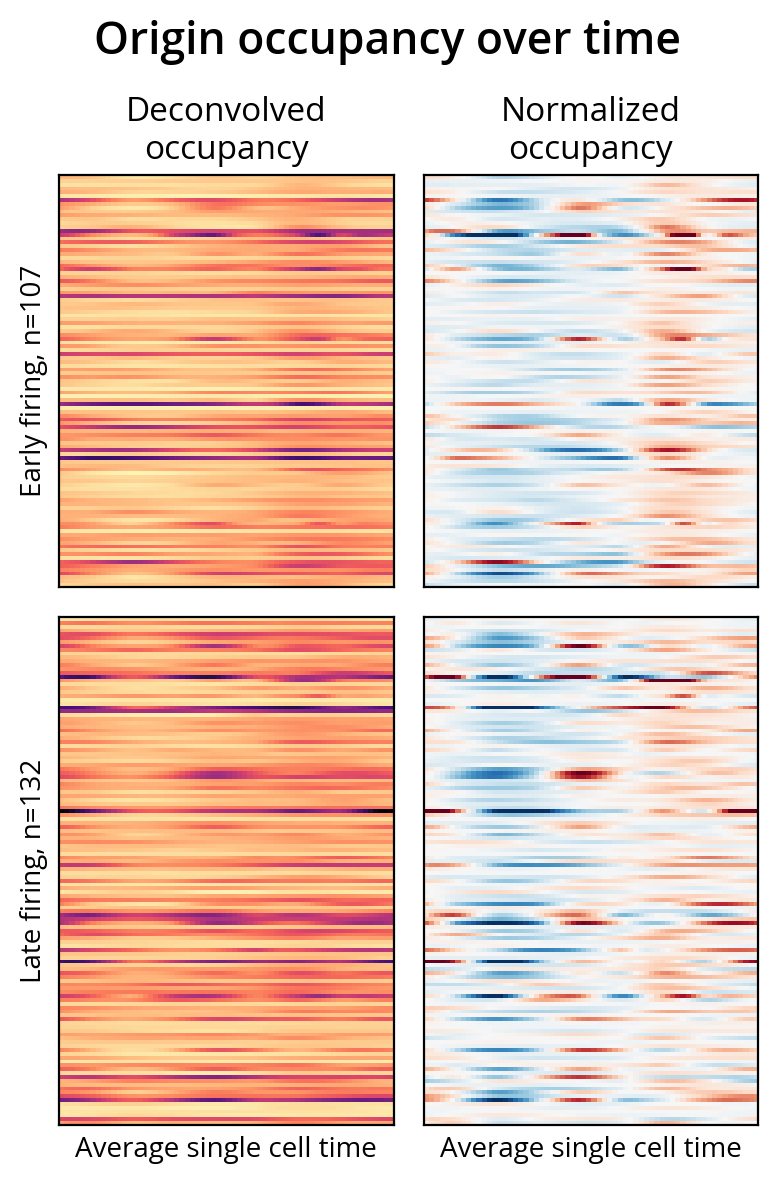

In [844]:
# Visualize the results
consensus_analysis.plot_origin_correlation_heatmap(time_indices=t_indices)


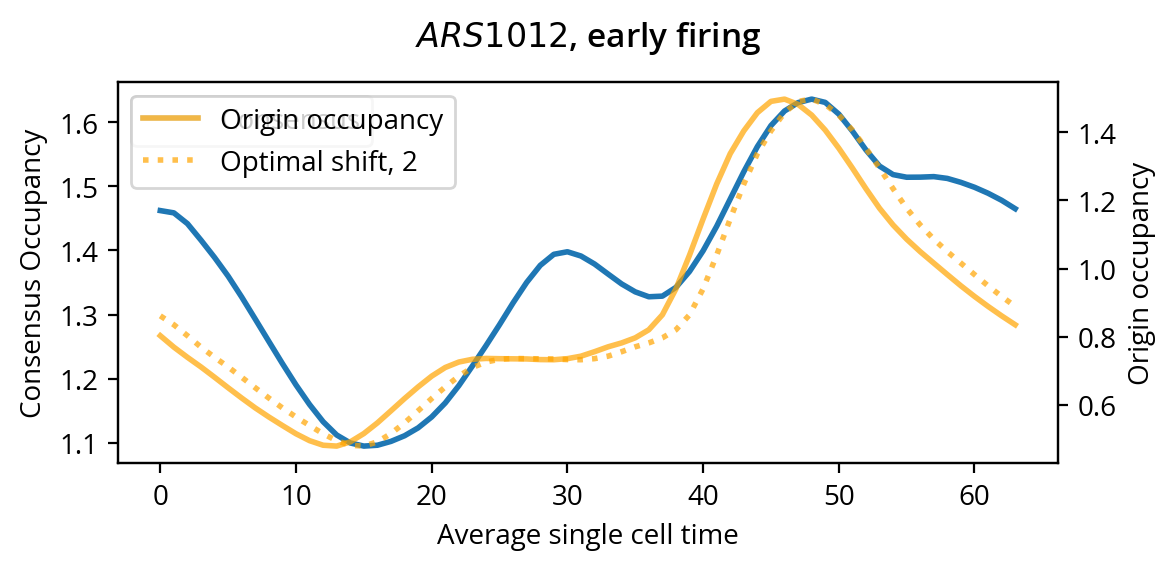

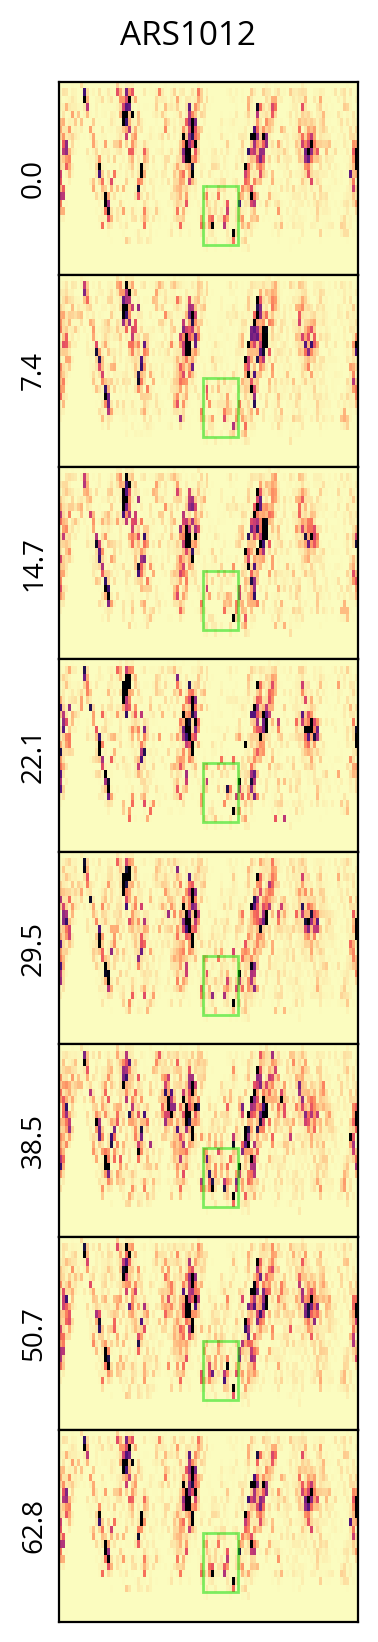

In [902]:
early_origin_id = 'oridb_437'
late_origin_id = 'oridb_498'

consensus_analysis.plot_consensus_vs_origin(origin_id=early_origin_id,
    time_indices=t_indices, title="early firing")
deconv_origin_analysis_no_daughter.plot_origin_heatmap(early_origin_id, 't')

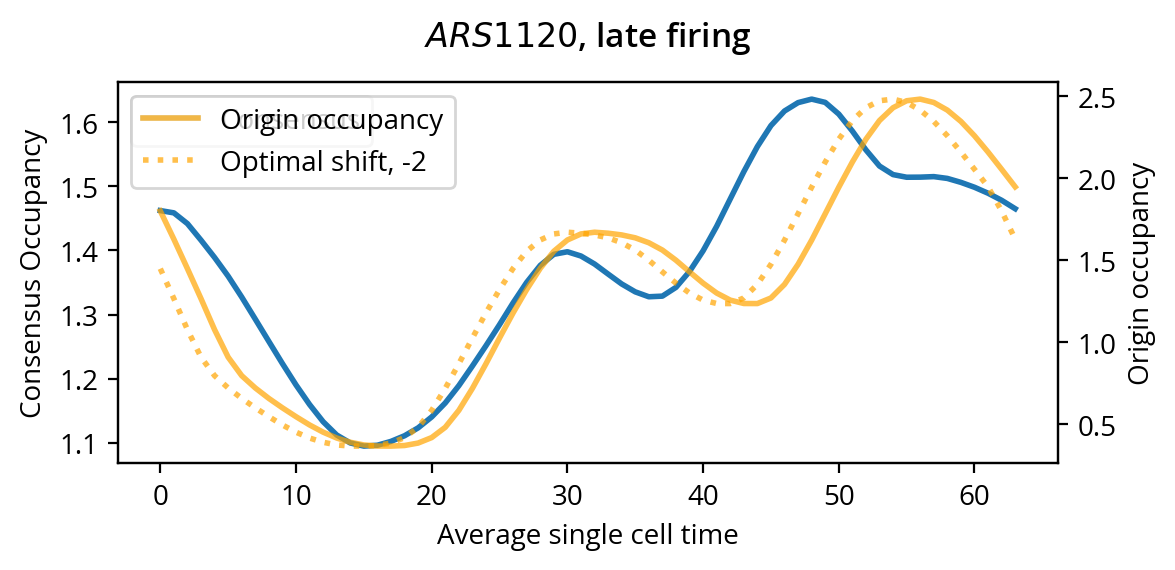

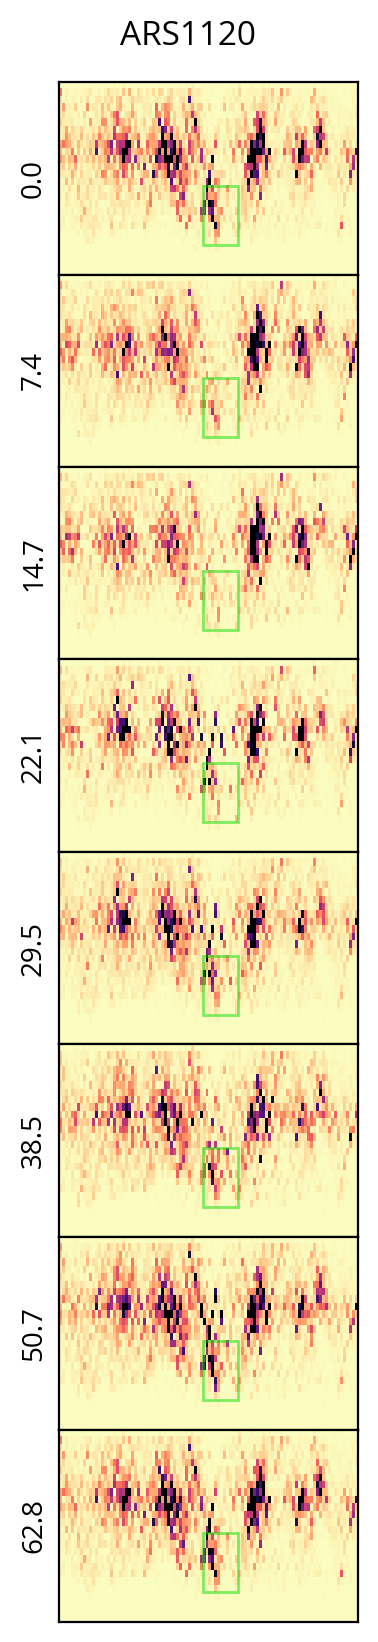

In [898]:
consensus_analysis.plot_consensus_vs_origin(origin_id=late_origin_id, 
    time_indices=t_indices, title="late firing")
deconv_origin_analysis_no_daughter.plot_origin_heatmap(late_origin_id, 't')

In [936]:
from pipeline.origin_analysis_runner import DeconvolvedOriginAnalysisRunner

save_directory = 'output/prototype_pipeline_subset/origin_analyses'

runner = DeconvolvedOriginAnalysisRunner(
    chromatin_data_directory=chromatin_data_path_nodaughter,
    save_directory=save_directory)

[0:20:12] Starting full analysis pipeline...
[0:20:12] Generating and saving figures...
[0:20:16] All figures saved to output/prototype_pipeline_subset/origin_analyses
[0:20:16] Full analysis pipeline completed.
[0:20:16] Top 15 early and late origins saved to CSV.


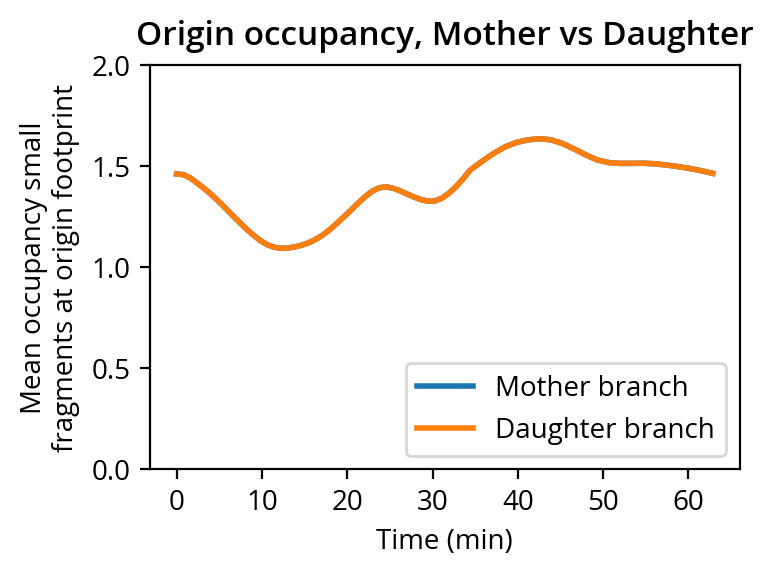

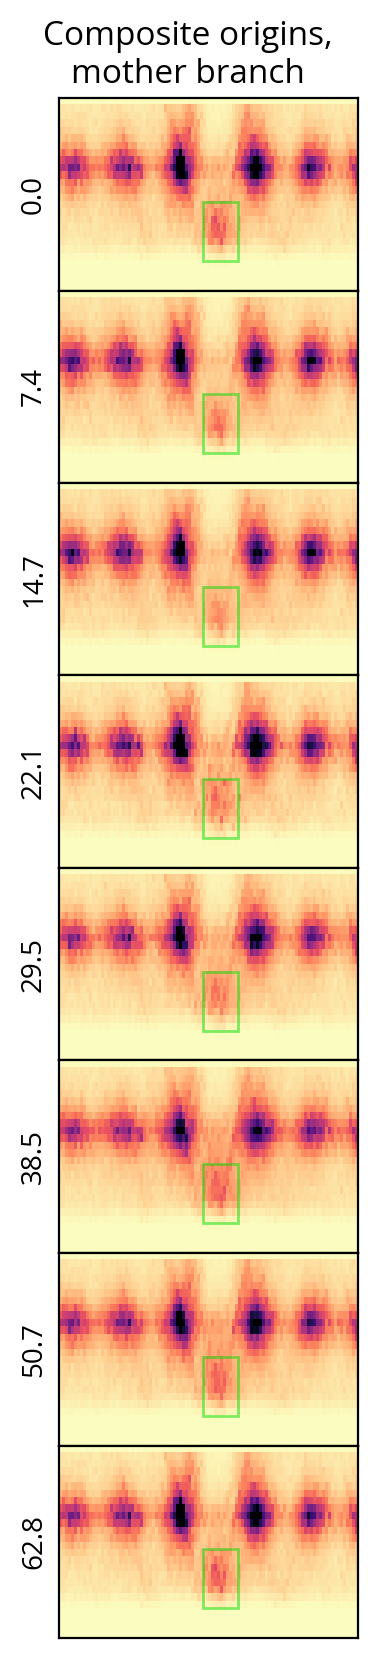

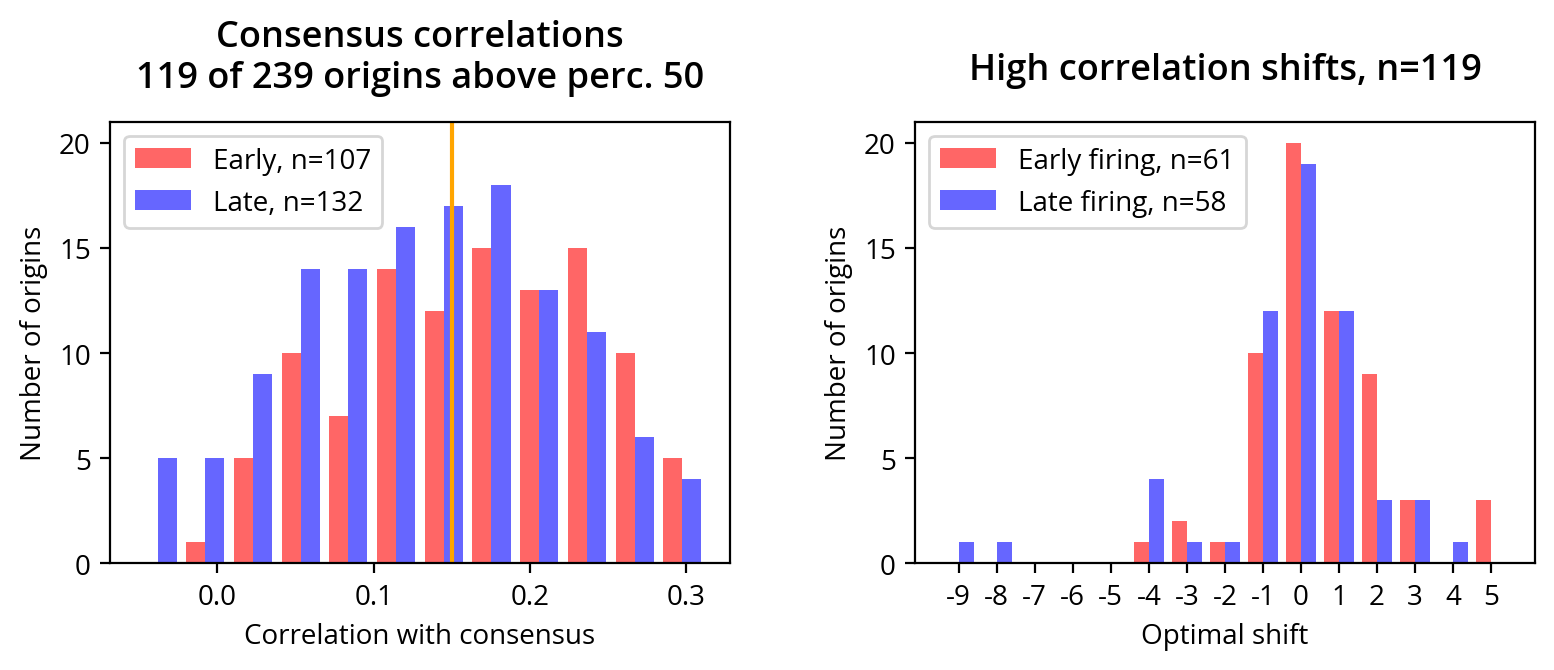

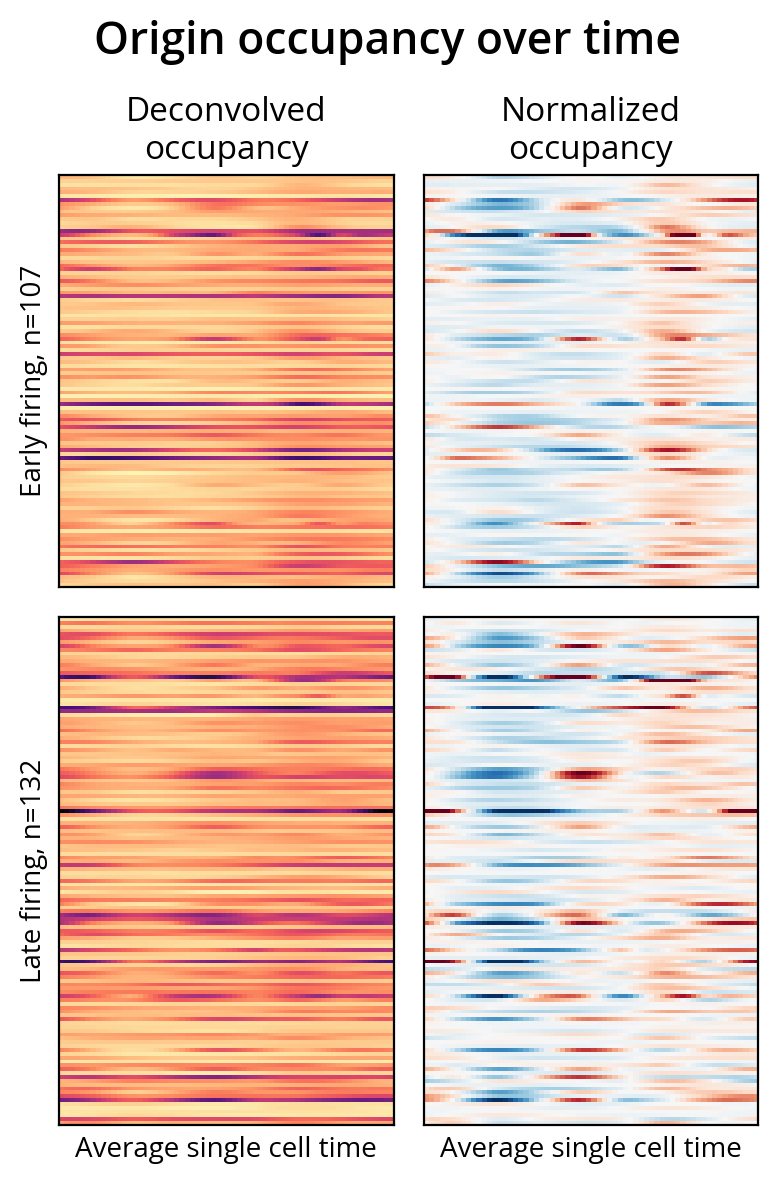

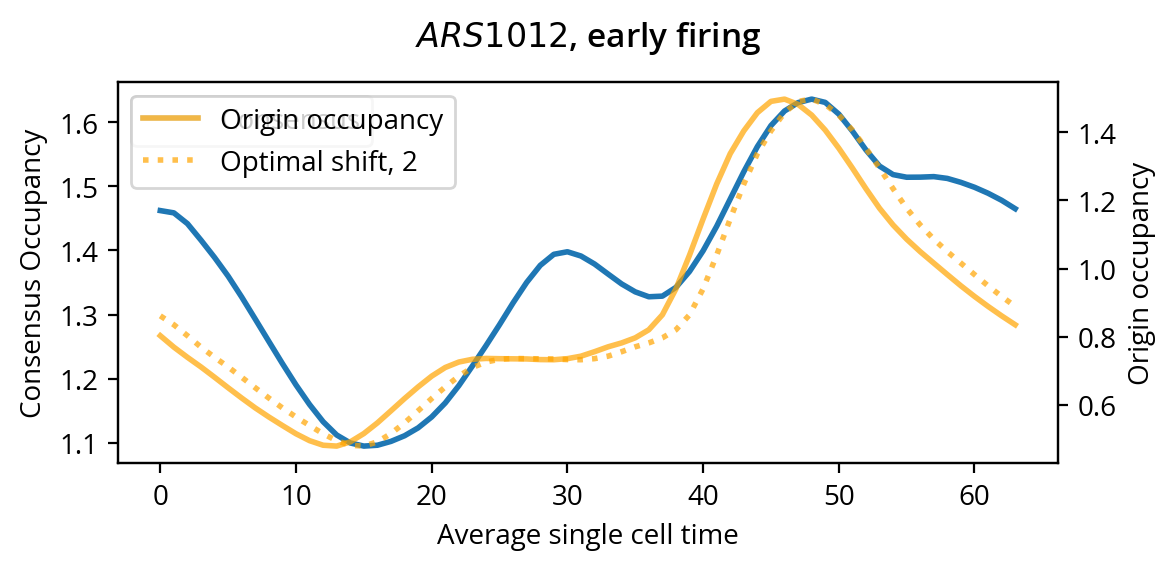

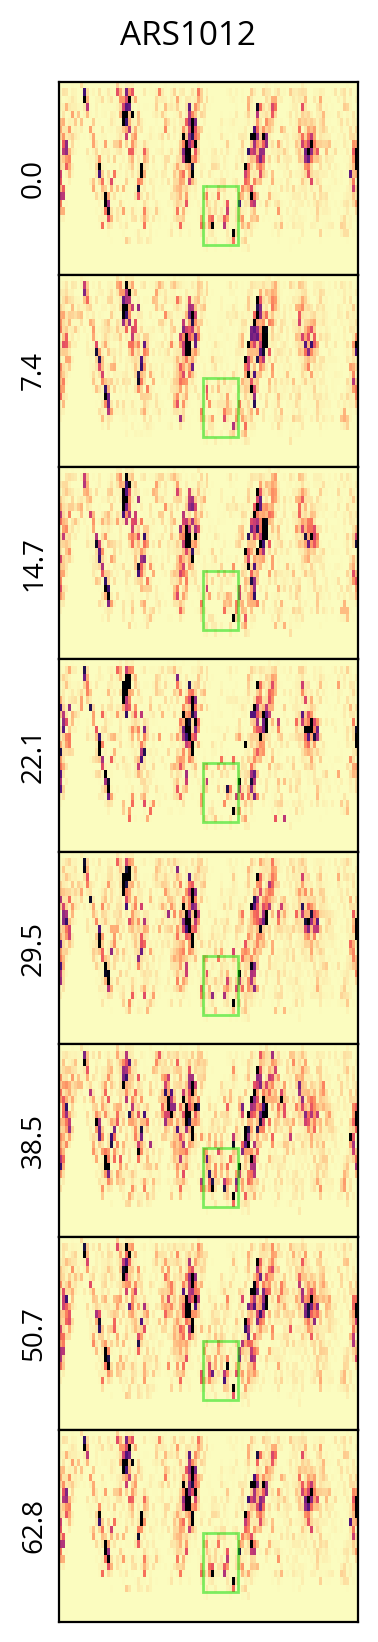

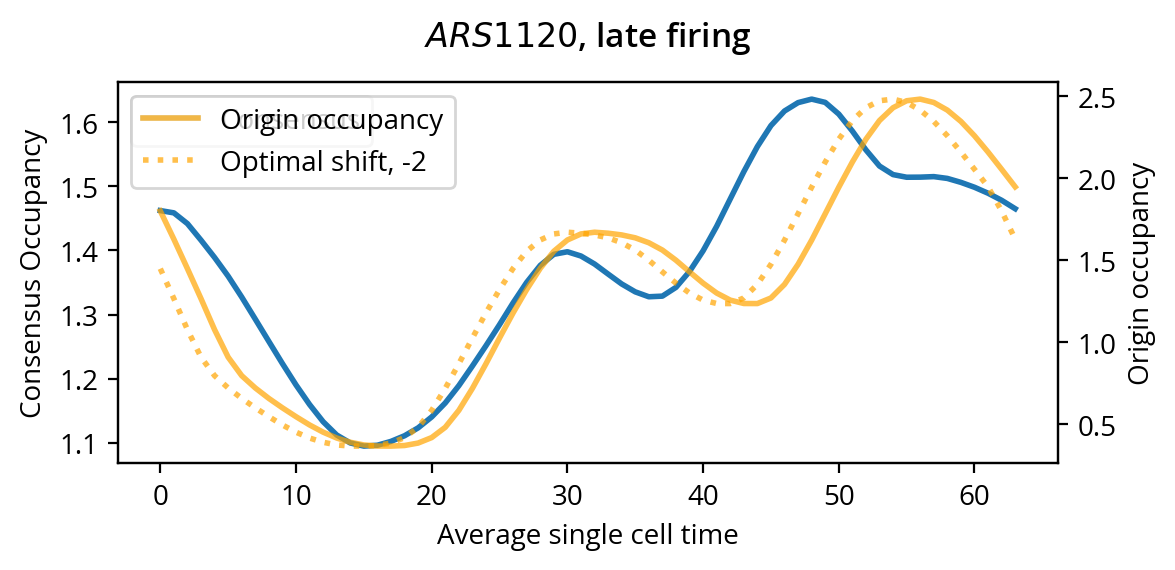

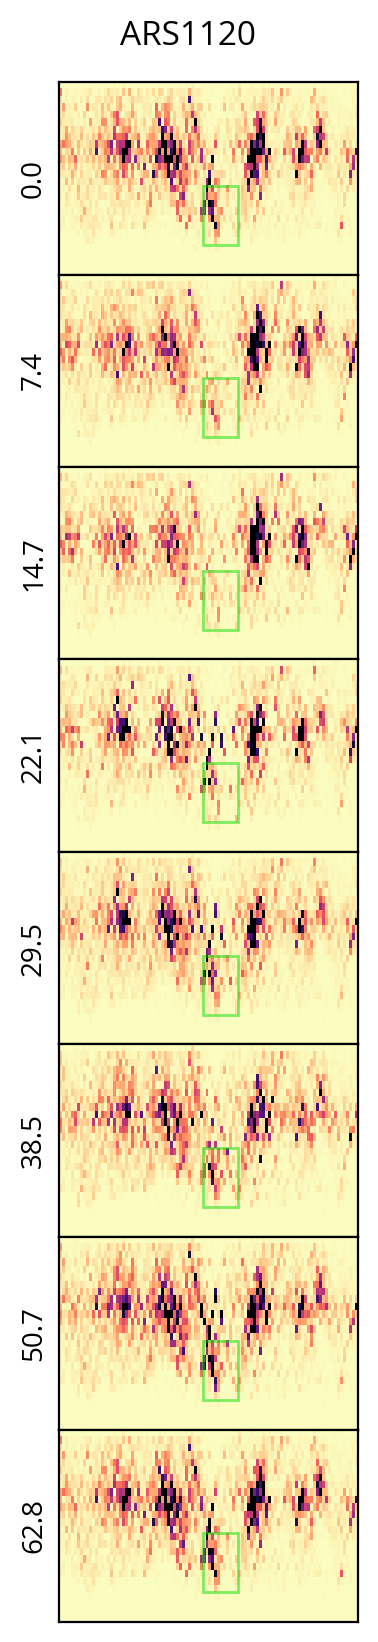

In [945]:
t_indices = config1.t_indices()

# Run full analysis
runner.analyze_all_origins(time_indices=t_indices)

# Get top early and late origins
early_origins, late_origins = runner.get_early_and_late_origins(n=15)